In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "risultati").exists():
    fallback = Path(r"C:\Users\acer\Desktop\ProgettoTesi")
    if fallback.exists():
        PROJECT_DIR = fallback

PROFILE_DIR = PROJECT_DIR / "risultati" / "profilazione_acustica"
TURN_LABELS_CSV = PROFILE_DIR / "turni_con_label_acustica.csv"
OUTPUT_DIR = PROFILE_DIR / "controlli_behavioral"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MAX_TURNS_PER_PATIENT_FIT = 25
MIN_CLUSTER_SHARE = 0.08
K_VALUES = [2, 3, 4, 5]
N_STABILITY_RUNS = 20

print("TURN_LABELS_CSV:", TURN_LABELS_CSV)
print("Esiste:", TURN_LABELS_CSV.exists())
if not TURN_LABELS_CSV.exists():
    raise FileNotFoundError("Eseguire prima il notebook 11 fino al salvataggio di turni_con_label_acustica.csv")


TURN_LABELS_CSV: c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\turni_con_label_acustica.csv
Esiste: True


In [2]:
turns = pd.read_csv(TURN_LABELS_CSV)

FORBIDDEN = ["dn4", "bpi", "nrs"]
clinical_columns = [
    col for col in turns.columns
    if any(term in str(col).lower() for term in FORBIDDEN)
]

print("Turni:", len(turns))
print("Pazienti:", turns["patient_id"].nunique())
print("Registrazioni:", turns["recording_id"].nunique())
print("Colonne cliniche trovate:", clinical_columns)

if clinical_columns:
    raise RuntimeError("Questa fase deve essere indipendente dagli score clinici.")


Turni: 3825
Pazienti: 90
Registrazioni: 92
Colonne cliniche trovate: []


## 1. Quota di cluster 1 a livello paziente

,cluster_1_share
count,90.000000
mean,0.248659
std,0.178912
min,0.000000
25%,0.112676
50%,0.225403
75%,0.352067
max,0.897436


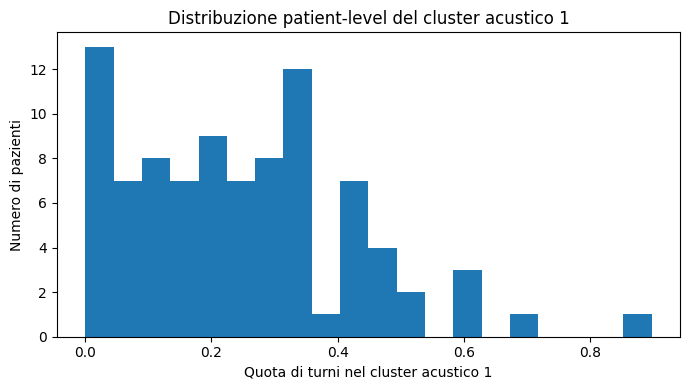

Pazienti con quota cluster 1 più alta:


,patient_id,n_turns,cluster_1_share,cluster_1_count
37,51,39,0.897436,35
15,22,51,0.705882,36
33,47,37,0.594595,22
35,49,46,0.586957,27
77,126,46,0.586957,27
70,112,44,0.500000,22
36,50,16,0.500000,8
31,45,41,0.487805,20
75,121,35,0.485714,17
49,67,55,0.472727,26


In [3]:
patient_state = (
    turns.groupby("patient_id")
    .agg(
        n_turns=("turn_id", "size"),
        cluster_1_share=("acoustic_cluster", lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") == 1))),
        cluster_1_count=("acoustic_cluster", lambda s: int(np.sum(pd.to_numeric(s, errors="coerce") == 1))),
    )
    .reset_index()
)

display(patient_state["cluster_1_share"].describe().to_frame())

plt.figure(figsize=(7,4))
plt.hist(patient_state["cluster_1_share"], bins=20)
plt.xlabel("Quota di turni nel cluster acustico 1")
plt.ylabel("Numero di pazienti")
plt.title("Distribuzione patient-level del cluster acustico 1")
plt.tight_layout()
plt.show()

print("Pazienti con quota cluster 1 più alta:")
display(patient_state.sort_values("cluster_1_share", ascending=False).head(15))


## 2. Controlli di possibili confondenti tecnici

In [4]:

TECHNICAL_CHECKS = ["turn_duration_seconds", "peak_amplitude", "clipping_ratio"]
technical_rows = []

for feature in TECHNICAL_CHECKS:
    if feature not in turns.columns:
        continue
    temp = pd.DataFrame({
        "cluster": turns["acoustic_cluster"],
        "value": pd.to_numeric(turns[feature], errors="coerce"),
    }).dropna()
    for cluster_id, group in temp.groupby("cluster"):
        technical_rows.append({
            "feature": feature,
            "cluster": int(cluster_id),
            "n": int(len(group)),
            "median": float(group["value"].median()),
            "mean": float(group["value"].mean()),
            "p25": float(group["value"].quantile(.25)),
            "p75": float(group["value"].quantile(.75)),
        })

technical_summary = pd.DataFrame(technical_rows)
display(technical_summary)

if "canale" in turns.columns:
    print("Distribuzione cluster condizionata al canale:")
    display(pd.crosstab(turns["canale"], turns["acoustic_label"], normalize="index").round(3))

recording_share = (
    turns.groupby("recording_id")["acoustic_cluster"]
    .apply(lambda s: float(np.mean(pd.to_numeric(s, errors="coerce") == 1)))
    .rename("cluster_1_share")
    .reset_index()
)

print("Registrazioni con quota cluster 1 più alta:")
display(recording_share.sort_values("cluster_1_share", ascending=False).head(15))

technical_summary.to_csv(OUTPUT_DIR / "controllo_confondenti_tecnici.csv", index=False)
recording_share.to_csv(OUTPUT_DIR / "quota_cluster1_per_registrazione.csv", index=False)
patient_state.to_csv(OUTPUT_DIR / "quota_cluster1_per_paziente.csv", index=False)


,feature,cluster,n,median,mean,p25,p75
0,turn_duration_seconds,0,2888,2.017000,3.326474e+00,1.097000,3.763000
1,turn_duration_seconds,1,937,1.097000,1.701081e+00,0.759000,1.772000
2,peak_amplitude,0,2888,0.185575,2.201732e-01,0.114718,0.293442
3,peak_amplitude,1,937,0.159893,2.080165e-01,0.091191,0.268295
4,clipping_ratio,0,2888,0.000000,7.543142e-09,0.000000,0.000000
5,clipping_ratio,1,937,0.000000,0.000000e+00,0.000000,0.000000


Distribuzione cluster condizionata al canale:


acoustic_label,cluster_0,cluster_1
canale,,
destro,0.808,0.192
mono,0.774,0.226
sinistro,0.722,0.278


Registrazioni con quota cluster 1 più alta:


,recording_id,cluster_1_share
62,ID51.StudioRuggi,0.897436
37,ID22.StudioRuggi,0.705882
58,ID47.StudioRuggi,0.594595
14,ID126.StudioRuggi,0.586957
60,ID49.StudioRuggi,0.586957
6,ID112.StudioRuggi,0.500000
61,ID50.StudioRuggi,0.500000
56,ID45.StudioRuggi,0.487805
12,ID121.StudioRuggi,0.485714
74,ID67.StudioRuggi,0.472727



## 3. Spazio comportamentale/prosodico

Per il secondo clustering escludiamo le feature spettrali (`flatness`, `centroid`, `bandwidth`) che dominavano il profilo acustico generale e usiamo solo:

- speech activity ratio;
- durata media delle pause interne;
- parole al secondo;
- filler/esitazioni;
- ripetizioni;
- variabilità del pitch (`f0_std`, `f0_iqr`).


In [5]:
BEHAVIORAL_FEATURES = [
    "speech_activity_ratio",
    "internal_pause_mean_seconds",
    "words_per_second",
    "filler_rate_per_100_words",
    "repetition_rate_per_100_words",
    "f0_std",
    "f0_iqr",
]

missing_behavioral = [f for f in BEHAVIORAL_FEATURES if f not in turns.columns]
if missing_behavioral:
    raise ValueError(f"Feature comportamentali mancanti: {missing_behavioral}")

qc = []
for feature in BEHAVIORAL_FEATURES:
    values = pd.to_numeric(turns[feature], errors="coerce")
    qc.append({
        "feature": feature,
        "missing_percent": float(100 * values.isna().mean()),
        "n_unique": int(values.dropna().nunique()),
    })
behavioral_qc = pd.DataFrame(qc)
display(behavioral_qc)


,feature,missing_percent,n_unique
0,speech_activity_ratio,0.000000,1968
1,internal_pause_mean_seconds,0.000000,177
2,words_per_second,0.000000,1946
3,filler_rate_per_100_words,5.464052,20
4,repetition_rate_per_100_words,5.464052,41
5,f0_std,6.823529,3559
6,f0_iqr,6.823529,3419


In [6]:
X = turns[BEHAVIORAL_FEATURES].apply(pd.to_numeric, errors="coerce").copy()

# Winsorization 1%-99%
for col in X.columns:
    valid = X[col].dropna()
    if valid.empty:
        continue
    X[col] = X[col].clip(valid.quantile(.01), valid.quantile(.99))

# Log1p per feature non negative fortemente asimmetriche
for col in ["internal_pause_mean_seconds", "filler_rate_per_100_words", "repetition_rate_per_100_words"]:
    X[col] = np.log1p(X[col])

imputer = SimpleImputer(strategy="median")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(imputer.fit_transform(X))
print("Shape spazio comportamentale:", X_scaled.shape)


Shape spazio comportamentale: (3825, 7)


## 4. Fit bilanciato e scelta di k

In [7]:
fit_indices = []
for patient_id, group in turns.groupby("patient_id"):
    n = min(len(group), MAX_TURNS_PER_PATIENT_FIT)
    sampled = group.sample(n=n, random_state=RANDOM_STATE + int(patient_id))
    fit_indices.extend(sampled.index.tolist())

fit_indices = np.asarray(sorted(fit_indices), dtype=int)
X_fit = X_scaled[fit_indices]

print("Turni nel fit:", len(fit_indices))
print("Pazienti nel fit:", turns.loc[fit_indices, "patient_id"].nunique())

rows = []
for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_fit)
    counts = np.bincount(labels, minlength=k)
    min_share = float(counts.min() / len(labels))
    rows.append({
        "k": k,
        "silhouette": float(silhouette_score(X_fit, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X_fit, labels)),
        "davies_bouldin": float(davies_bouldin_score(X_fit, labels)),
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "min_cluster_share": min_share,
        "passes_min_cluster_share": min_share >= MIN_CLUSTER_SHARE,
    })

behavioral_selection = pd.DataFrame(rows)
display(behavioral_selection.round(4))

valid = behavioral_selection[behavioral_selection["passes_min_cluster_share"]].copy()
if valid.empty:
    valid = behavioral_selection.copy()

BEST_K_BEHAVIOR = int(
    valid.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["k"]
)
print("BEST_K comportamentale:", BEST_K_BEHAVIOR)


Turni nel fit: 2164
Pazienti nel fit: 90


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,min_cluster_share,passes_min_cluster_share
0,2,0.3050,746.7095,1.4572,674,1490,0.3115,True
1,3,0.3206,697.1575,1.1690,310,1377,0.1433,True
2,4,0.2569,703.1121,1.2297,290,793,0.1340,True
3,5,0.2603,667.2589,1.1578,109,725,0.0504,False


BEST_K comportamentale: 3


## 5. Stabilità

In [8]:
runs = []
for run in range(N_STABILITY_RUNS):
    model = KMeans(n_clusters=BEST_K_BEHAVIOR, n_init=20, random_state=RANDOM_STATE + run)
    runs.append(model.fit_predict(X_fit))

ari = []
for i in range(len(runs)):
    for j in range(i+1, len(runs)):
        ari.append(adjusted_rand_score(runs[i], runs[j]))

print("ARI medio:", round(float(np.mean(ari)), 4))
print("ARI minimo:", round(float(np.min(ari)), 4))
print("ARI massimo:", round(float(np.max(ari)), 4))


ARI medio: 1.0
ARI minimo: 1.0
ARI massimo: 1.0


## 6. Label comportamentali e confronto con il clustering generale

In [9]:
behavior_model = KMeans(n_clusters=BEST_K_BEHAVIOR, n_init=100, random_state=RANDOM_STATE)
behavior_model.fit(X_fit)
behavior_labels = behavior_model.predict(X_scaled)

turns_behavior = turns.copy()
turns_behavior["behavioral_cluster"] = behavior_labels.astype(int)
turns_behavior["behavioral_label"] = "behavior_cluster_" + turns_behavior["behavioral_cluster"].astype(str)

print("Distribuzione turn-level:")
display(turns_behavior["behavioral_label"].value_counts().sort_index().rename("n_turns").to_frame())

ari_between = adjusted_rand_score(turns_behavior["acoustic_cluster"], turns_behavior["behavioral_cluster"])
print("ARI tra clustering acustico generale e comportamentale:", round(float(ari_between), 4))

display(pd.crosstab(
    turns_behavior["acoustic_label"],
    turns_behavior["behavioral_label"],
    normalize="index"
).round(3))


Distribuzione turn-level:


,n_turns
behavioral_label,
behavior_cluster_0,603
behavior_cluster_1,2307
behavior_cluster_2,915


ARI tra clustering acustico generale e comportamentale: -0.0346


behavioral_label,behavior_cluster_0,behavior_cluster_1,behavior_cluster_2
acoustic_label,,,
cluster_0,0.167,0.563,0.270
cluster_1,0.128,0.727,0.145


## 7. Profilo dei cluster comportamentali

,speech_activity_ratio,internal_pause_mean_seconds,words_per_second,filler_rate_per_100_words,repetition_rate_per_100_words,f0_std,f0_iqr
behavioral_cluster,,,,,,,
0,-1.938,0.255,-0.174,0.053,0.223,0.201,0.160
1,0.057,0.014,0.127,0.057,0.072,-0.301,-0.259
2,-0.216,0.046,0.042,0.043,0.089,1.076,1.375


Varianza PCA1+PCA2: 0.6416


NameError: name 'FIGURE_DIR' is not defined

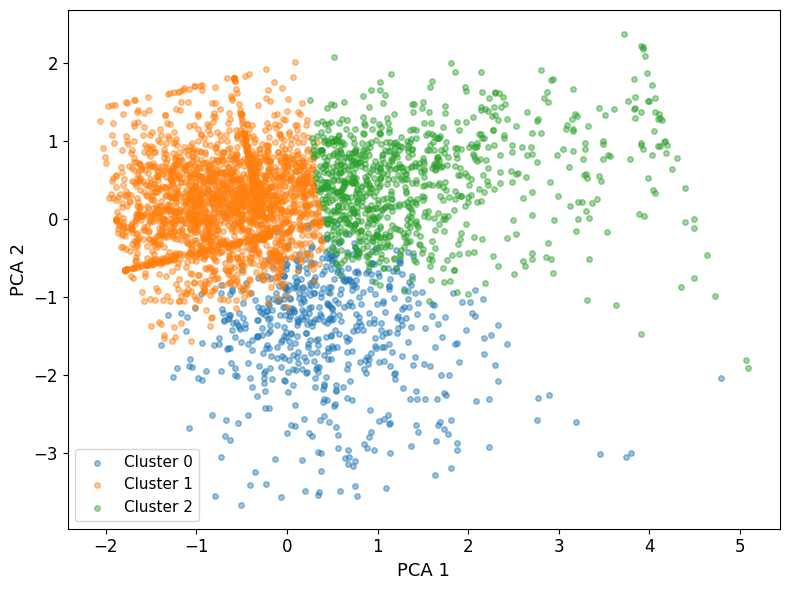

In [10]:
profile = pd.DataFrame(X_scaled, columns=BEHAVIORAL_FEATURES, index=turns_behavior.index)
profile["behavioral_cluster"] = turns_behavior["behavioral_cluster"].values
behavior_profile = profile.groupby("behavioral_cluster")[BEHAVIORAL_FEATURES].mean()
display(behavior_profile.round(3))

# PCA solo per visualizzazione
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
p = pca.fit_transform(X_scaled)
print("Varianza PCA1+PCA2:", round(float(pca.explained_variance_ratio_[:2].sum()), 4))

fig, ax = plt.subplots(figsize=(8, 6))

for cluster_id in sorted(
    turns_behavior["behavioral_cluster"].unique()
):
    mask = (
        turns_behavior["behavioral_cluster"].to_numpy()
        == cluster_id
    )

    ax.scatter(
        p[mask, 0],
        p[mask, 1],
        s=16,
        alpha=0.45,
        label=f"Cluster {cluster_id}",
    )

ax.set_xlabel("PCA 1", fontsize=13)
ax.set_ylabel("PCA 2", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=11)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "profili_comportamentali_prosodici_pca.pdf",
    bbox_inches="tight",
)

plt.show()


## 8. Aggregazione a livello paziente

In [11]:
cluster_ids = sorted(turns_behavior["behavioral_cluster"].unique())
rows = []

for patient_id, group in turns_behavior.groupby("patient_id"):
    counts = group["behavioral_cluster"].value_counts().reindex(cluster_ids, fill_value=0)
    shares = counts / counts.sum()
    row = {"patient_id": int(patient_id), "n_turns": int(len(group))}
    for cid in cluster_ids:
        row[f"behavior_cluster_{cid}_share"] = float(shares.loc[cid])
        row[f"behavior_cluster_{cid}_count"] = int(counts.loc[cid])
    rows.append(row)

behavior_patient = pd.DataFrame(rows)
display(behavior_patient.head())

OUT_TURNS = OUTPUT_DIR / "turni_con_cluster_comportamentale.csv"
OUT_PATIENT = OUTPUT_DIR / "profili_comportamentali_patient_level.csv"
OUT_SELECTION = OUTPUT_DIR / "selezione_k_comportamentale.csv"
OUT_PROFILE = OUTPUT_DIR / "profilo_cluster_comportamentale.csv"

turns_behavior.to_csv(OUT_TURNS, index=False)
behavior_patient.to_csv(OUT_PATIENT, index=False)
behavioral_selection.to_csv(OUT_SELECTION, index=False)
behavior_profile.to_csv(OUT_PROFILE)

print("Output salvati:")
for path in [OUT_TURNS, OUT_PATIENT, OUT_SELECTION, OUT_PROFILE]:
    print(" -", path)


,patient_id,n_turns,behavior_cluster_0_share,behavior_cluster_0_count,behavior_cluster_1_share,behavior_cluster_1_count,behavior_cluster_2_share,behavior_cluster_2_count
0,1,34,0.382353,13,0.617647,21,0.000000,0
1,2,33,0.090909,3,0.666667,22,0.242424,8
2,3,28,0.178571,5,0.750000,21,0.071429,2
3,4,32,0.000000,0,0.312500,10,0.687500,22
4,10,22,0.000000,0,0.727273,16,0.272727,6


Output salvati:
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\controlli_behavioral\turni_con_cluster_comportamentale.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\controlli_behavioral\profili_comportamentali_patient_level.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\controlli_behavioral\selezione_k_comportamentale.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\controlli_behavioral\profilo_cluster_comportamentale.csv
